In [1]:
!pip install nltk spacy wordcloud matplotlib seaborn pandas scikit-learn
!pip install faker          # for pseudonymisation
!pip install diffprivlib    # IBM differential privacy library
!python -m spacy download en_core_web_sm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.9/176.9 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 92.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import pandas as pd
import numpy as np
import re
import string
import hashlib
import uuid
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# NLTK
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import pos_tag

# spaCy
import spacy
nlp = spacy.load("en_core_web_sm")

# Sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split

# WordCloud
from wordcloud import WordCloud

# ── Privacy libraries ──────────────────────────────────
from faker import Faker                         # pseudonymisation
import diffprivlib as dp                        # differential privacy
fake = Faker()

print("✅ All libraries (including privacy) loaded successfully!")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


✅ All libraries (including privacy) loaded successfully!


In [3]:
from google.colab import files
uploaded = files.upload()   # select dermatology.csv

df = pd.read_csv("dermatology.csv")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nLabel counts:\n{df['label'].value_counts()}")
df.head()


Saving dermatology.csv to dermatology (2).csv
Shape: (330, 2)

Columns: ['description', 'label']

Label counts:
label
acne                   15
actinic_keratosis      15
benign_tumors          15
bullous                15
candidiasis            15
drug_eruption          15
eczema                 15
infestations_bites     15
lichen                 15
lupus                  15
moles                  15
psoriasis              15
rosacea                15
seborrh_keratoses      15
skin_cancer            15
sun_sunlight_damage    15
tinea                  15
unknown_normal         15
vascular_tumors        15
vasculitis             15
vitiligo               15
warts                  15
Name: count, dtype: int64


,description,label
0,I’ve been getting small red bumps on my cheeks...,acne
1,"For about a month now, I’ve noticed several pa...",acne
2,I keep getting tiny bumps on my forehead that ...,acne
3,"Over the last three weeks, I’ve developed red ...",acne
4,I have several small bumps on my upper back an...,acne


       text_length  word_count
count   330.000000  330.000000
mean    159.772727   29.781818
std      25.214457    4.567059
min     106.000000   19.000000
25%     142.000000   27.000000
50%     157.000000   29.000000
75%     174.000000   33.000000
max     242.000000   44.000000


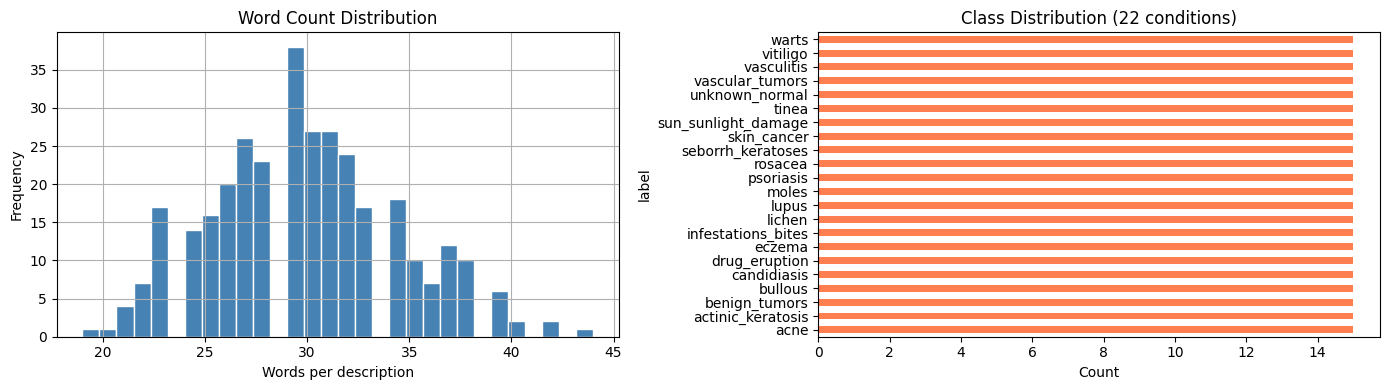

In [4]:
df['text_length'] = df['description'].apply(len)
df['word_count']  = df['description'].apply(lambda x: len(x.split()))

print(df[['text_length', 'word_count']].describe())

plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
df['word_count'].hist(bins=30, color='steelblue', edgecolor='white')
plt.title('Word Count Distribution')
plt.xlabel('Words per description')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
df['label'].value_counts().plot(kind='barh', color='coral')
plt.title('Class Distribution (22 conditions)')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

In [5]:
print("Missing values:\n", df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

df = df.drop_duplicates().reset_index(drop=True)
print(f"\nClean dataset shape: {df.shape}")

Missing values:
 description    0
label          0
text_length    0
word_count     0
dtype: int64

Duplicate rows: 0

Clean dataset shape: (330, 4)


In [6]:
def clean_text(text):
    """
    Cleaning steps:
      0. [NEW] Strip obvious PII patterns
      1. Lowercase
      2. Remove URLs
      3. Remove HTML tags
      4. Remove punctuation
      5. Remove digits
      6. Collapse whitespace
    """
    # 0. PII pattern removal ─────────────────────────────
    text = re.sub(r'\b[A-Z][a-z]+ [A-Z][a-z]+\b', '[NAME]', text)   # Proper names
    text = re.sub(r'\b\d{1,3}\s*(?:years?|yrs?)(?:\s*old)?\b',
                  '[AGE]', text, flags=re.IGNORECASE)                 # Ages
    text = re.sub(r'\b(?:\+?60|0)\d[\d\-]{7,10}\b', '[PHONE]', text) # MY phone numbers
    text = re.sub(r'\S+@\S+\.\S+', '[EMAIL]', text)                  # Emails
    text = re.sub(r'\b\d{5,6}\b', '[POSTCODE]', text)                # MY postcodes
    # ─────────────────────────────────────────────────────

    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned'] = df['description'].apply(clean_text)

print("Original :", df['description'][0])
print("\nCleaned  :", df['cleaned'][0])


Original : I’ve been getting small red bumps on my cheeks and forehead for the past two weeks. Some of them feel sore when I touch them, and a few have white tips that look like they might burst.

Cleaned  : i’ve been getting small red bumps on my cheeks and forehead for the past two weeks some of them feel sore when i touch them and a few have white tips that look like they might burst


In [7]:
PII_ENTITY_TYPES = {"PERSON", "DATE", "TIME", "GPE", "LOC", "ORG",
                    "CARDINAL", "MONEY", "ORDINAL", "FAC"}

def redact_pii_with_ner(text):
    """
    Runs spaCy NER on text and replaces detected
    PII entities with [ENTITY_TYPE] placeholders.
    Returns (redacted_text, list_of_redacted_items).
    """
    doc = nlp(text)
    redacted = text
    log = []
    # Process in reverse order to preserve character offsets
    for ent in reversed(doc.ents):
        if ent.label_ in PII_ENTITY_TYPES:
            placeholder = f"[{ent.label_}]"
            redacted = redacted[:ent.start_char] + placeholder + redacted[ent.end_char:]
            log.append((ent.text, ent.label_))
    return redacted, log

# Apply redaction
redaction_results     = df['cleaned'].apply(redact_pii_with_ner)
df['redacted_text']   = redaction_results.apply(lambda x: x[0])
df['redacted_items']  = redaction_results.apply(lambda x: x[1])

# Report
total_redacted = df['redacted_items'].apply(len).sum()
rows_affected  = df['redacted_items'].apply(lambda x: len(x) > 0).sum()
print(f"✅ PII Redaction complete")
print(f"   Total entities redacted : {total_redacted}")
print(f"   Rows affected           : {rows_affected} / {len(df)}")

# Show a before/after example
example_idx = df[df['redacted_items'].apply(len) > 0].index
if len(example_idx):
    i = example_idx[0]
    print(f"\nBefore: {df['cleaned'][i]}")
    print(f"After : {df['redacted_text'][i]}")
    print(f"Items : {df['redacted_items'][i]}")


✅ PII Redaction complete
   Total entities redacted : 292
   Rows affected           : 267 / 330

Before: i’ve been getting small red bumps on my cheeks and forehead for the past two weeks some of them feel sore when i touch them and a few have white tips that look like they might burst
After : i’ve been getting small red bumps on my cheeks and forehead for [DATE] some of them feel sore when i touch them and a few have white tips that look like they might burst
Items : [('the past two weeks', 'DATE')]


In [8]:
# Use redacted_text as the input from this point forward
df['tokens_word'] = df['redacted_text'].apply(word_tokenize)
df['tokens_sent'] = df['description'].apply(sent_tokenize)   # original for sentence structure

def spacy_tokenize(text):
    doc = nlp(text)
    return [(token.text, token.pos_) for token in doc if not token.is_space]

df['tokens_spacy'] = df['redacted_text'].apply(spacy_tokenize)

print("Word tokens (NLTK):\n", df['tokens_word'][0][:15])
print("\nspaCy tokens (word, POS):\n", df['tokens_spacy'][0][:10])


Word tokens (NLTK):
 ['i', '’', 've', 'been', 'getting', 'small', 'red', 'bumps', 'on', 'my', 'cheeks', 'and', 'forehead', 'for', '[']

spaCy tokens (word, POS):
 [('i', 'PRON'), ('’ve', 'AUX'), ('been', 'AUX'), ('getting', 'VERB'), ('small', 'ADJ'), ('red', 'ADJ'), ('bumps', 'NOUN'), ('on', 'ADP'), ('my', 'PRON'), ('cheeks', 'NOUN')]


In [9]:
STOPWORDS = set(stopwords.words('english'))
KEEP_WORDS = {'not', 'no', 'nor', 'neither', 'never', 'without'}
STOPWORDS  = STOPWORDS - KEEP_WORDS

def remove_stopwords(tokens):
    return [t for t in tokens if t not in STOPWORDS]

df['tokens_no_sw'] = df['tokens_word'].apply(remove_stopwords)

print("Before:", len(df['tokens_word'][0]), "→ After:", len(df['tokens_no_sw'][0]))


Before: 38 → After: 19


In [10]:
stemmer = PorterStemmer()

def stem_tokens(tokens):
    return [stemmer.stem(t) for t in tokens]

df['tokens_stemmed'] = df['tokens_no_sw'].apply(stem_tokens)

print("Stemmed:", df['tokens_stemmed'][0][:10])


Stemmed: ['’', 'get', 'small', 'red', 'bump', 'cheek', 'forehead', '[', 'date', ']']


In [11]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(treebank_tag):
    from nltk.corpus import wordnet
    if treebank_tag.startswith('J'): return wordnet.ADJ
    elif treebank_tag.startswith('V'): return wordnet.VERB
    elif treebank_tag.startswith('N'): return wordnet.NOUN
    elif treebank_tag.startswith('R'): return wordnet.ADV
    else: return wordnet.NOUN

def lemmatize_tokens(tokens):
    pos_tagged = pos_tag(tokens)
    return [lemmatizer.lemmatize(word, get_wordnet_pos(pos))
            for word, pos in pos_tagged]

df['tokens_lemma_nltk']  = df['tokens_no_sw'].apply(lemmatize_tokens)

def lemmatize_spacy(text):
    doc = nlp(text)
    return [token.lemma_ for token in doc
            if not token.is_stop and not token.is_punct and not token.is_space]

df['tokens_lemma_spacy'] = df['redacted_text'].apply(lemmatize_spacy)

print("NLTK lemmatized:", df['tokens_lemma_nltk'][0][:10])
print("spaCy lemmatized:", df['tokens_lemma_spacy'][0][:10])


NLTK lemmatized: ['’', 'get', 'small', 'red', 'bump', 'cheek', 'forehead', '[', 'DATE', ']']
spaCy lemmatized: ['get', 'small', 'red', 'bump', 'cheek', 'forehead', 'date', 'feel', 'sore', 'touch']


In [12]:
def check_residual_pii(text):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents
            if ent.label_ in PII_ENTITY_TYPES]

df['residual_pii'] = df['redacted_text'].apply(check_residual_pii)

residual_count = df['residual_pii'].apply(len).sum()
if residual_count == 0:
    print("PII Verification PASSED — no residual entities found in redacted text.")
else:
    print(f"WARNING: {residual_count} residual PII entities still detected!")
    flagged = df[df['residual_pii'].apply(len) > 0][['redacted_text', 'residual_pii']]
    print(flagged.head(10).to_string())


PII Verification PASSED — no residual entities found in redacted text.


In [13]:
df['processed_text'] = df['tokens_lemma_nltk'].apply(lambda x: ' '.join(x))

def top_ngrams(corpus, n=2, top_k=20):
    vec    = CountVectorizer(ngram_range=(n, n)).fit(corpus)
    bag    = vec.transform(corpus)
    counts = bag.sum(axis=0).A1
    vocab  = {v: k for k, v in vec.vocabulary_.items()}
    top    = sorted(zip(counts, [vocab[i] for i in range(len(counts))]), reverse=True)
    return top[:top_k]

print("Top 15 Bigrams:")
for count, ngram in top_ngrams(df['processed_text'], n=2, top_k=15):
    print(f"  {ngram:<35} {count}")

print("\nTop 15 Trigrams:")
for count, ngram in top_ngrams(df['processed_text'], n=3, top_k=15):
    print(f"  {ngram:<45} {count}")


Top 15 Bigrams:
  look like                           38
  start date                          32
  skin feel                           32
  appear date                         31
  date skin                           24
  slightly raise                      22
  doctor notice                       22
  date sometimes                      20
  sometimes feel                      19
  date itch                           19
  small red                           18
  red patch                           18
  notice small                        18
  skin look                           17
  date look                           17

Top 15 Trigrams:
  date area feel                                9
  sometimes feel slightly                       8
  look like tiny                                8
  date skin look                                8
  doctor notice small                           7
  date skin feel                                7
  date look like                                7
 

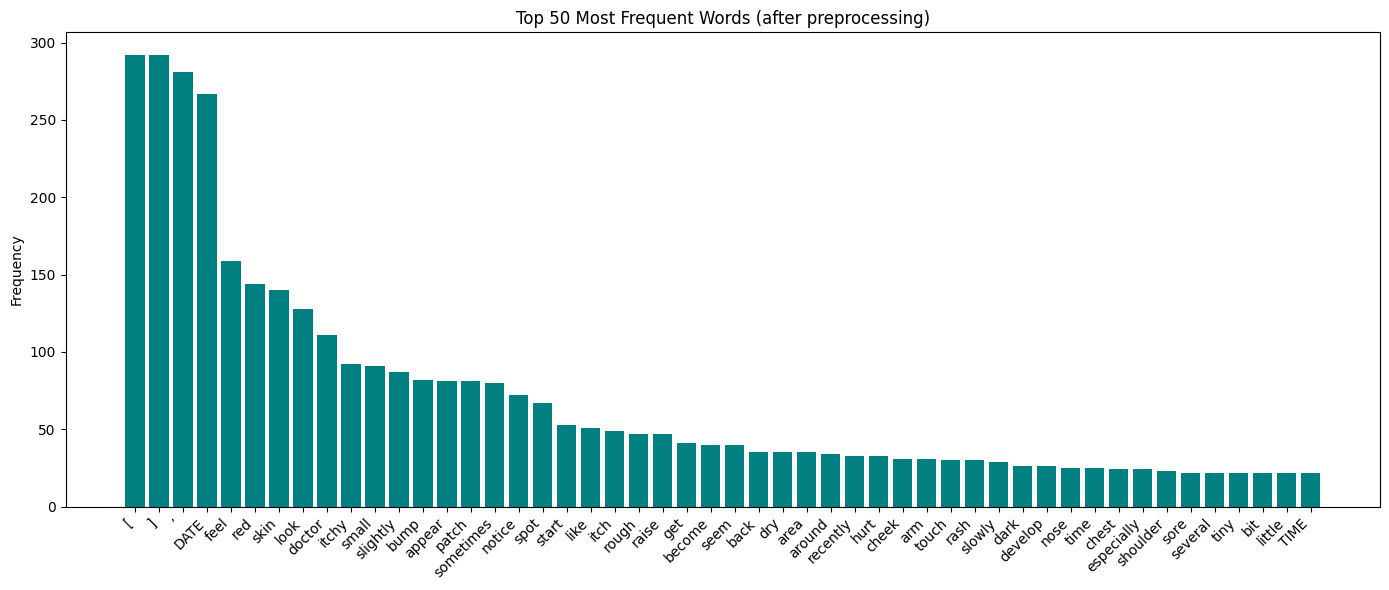

In [14]:
all_tokens = [token for tokens in df['tokens_lemma_nltk'] for token in tokens]
freq  = Counter(all_tokens)
top50 = freq.most_common(50)

words, counts = zip(*top50)
plt.figure(figsize=(14, 6))
plt.bar(words, counts, color='teal')
plt.xticks(rotation=45, ha='right')
plt.title('Top 50 Most Frequent Words (after preprocessing)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


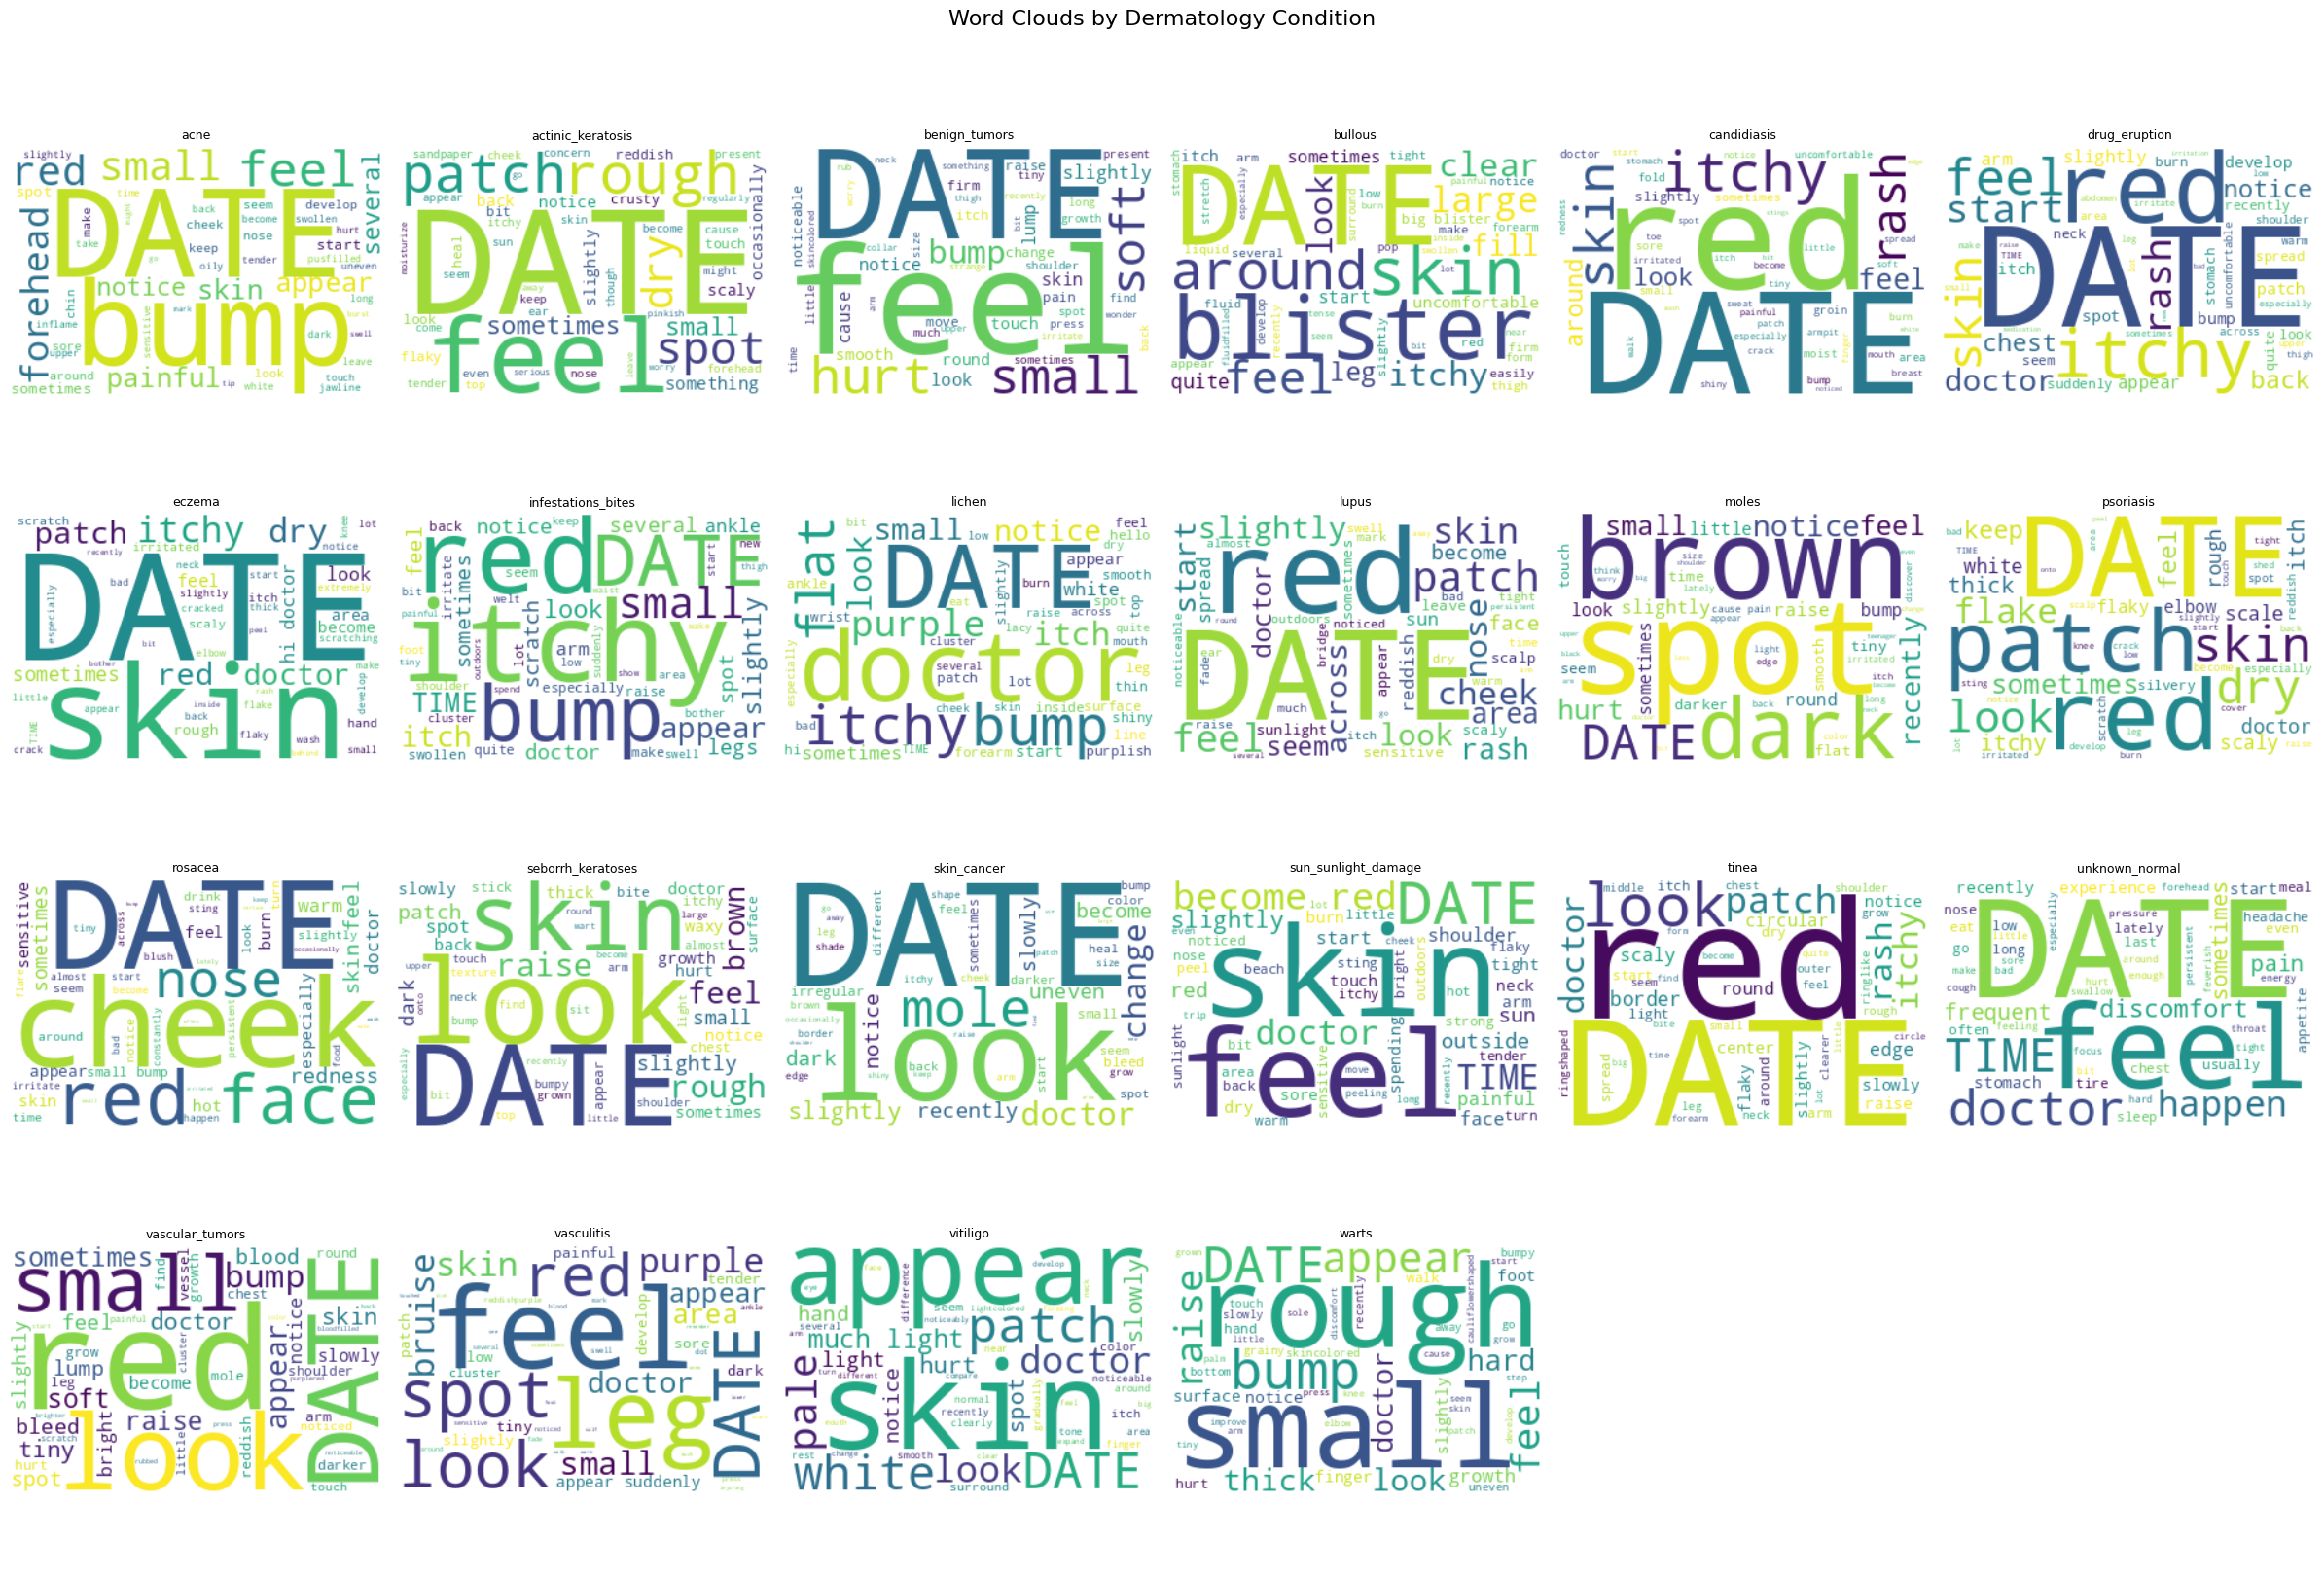

In [15]:
fig, axes = plt.subplots(4, 6, figsize=(24, 16))
axes = axes.flatten()

for i, label in enumerate(sorted(df['label'].unique())):
    text = ' '.join(df[df['label'] == label]['processed_text'].values)
    if text.strip():
        wc = WordCloud(width=300, height=200, background_color='white',
                       colormap='viridis', max_words=50).generate(text)
        axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(label, fontsize=9)
    axes[i].axis('off')

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Word Clouds by Dermatology Condition', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


In [16]:
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

label_map = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label → Encoded ID mapping:")
for k, v in label_map.items():
    print(f"  {k:<30} → {v}")


Label → Encoded ID mapping:
  acne                           → 0
  actinic_keratosis              → 1
  benign_tumors                  → 2
  bullous                        → 3
  candidiasis                    → 4
  drug_eruption                  → 5
  eczema                         → 6
  infestations_bites             → 7
  lichen                         → 8
  lupus                          → 9
  moles                          → 10
  psoriasis                      → 11
  rosacea                        → 12
  seborrh_keratoses              → 13
  skin_cancer                    → 14
  sun_sunlight_damage            → 15
  tinea                          → 16
  unknown_normal                 → 17
  vascular_tumors                → 18
  vasculitis                     → 19
  vitiligo                       → 20
  warts                          → 21


In [17]:
bow_vectorizer = CountVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
X_bow = bow_vectorizer.fit_transform(df['processed_text'])
print(f"BoW matrix shape: {X_bow.shape}")


BoW matrix shape: (330, 1029)


In [18]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000, ngram_range=(1, 2),
    min_df=2, sublinear_tf=True
)
X_tfidf      = tfidf_vectorizer.fit_transform(df['processed_text'])
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"TF-IDF matrix shape: {X_tfidf.shape}")

mean_tfidf    = X_tfidf.mean(axis=0).A1
top_tfidf_idx = mean_tfidf.argsort()[-20:][::-1]
print("\nTop 20 TF-IDF features:")
for idx in top_tfidf_idx:
    print(f"  {feature_names[idx]:<30} {mean_tfidf[idx]:.4f}")


TF-IDF matrix shape: (330, 1029)

Top 20 TF-IDF features:
  date                           0.0530
  feel                           0.0440
  red                            0.0416
  skin                           0.0407
  look                           0.0393
  doctor                         0.0371
  small                          0.0332
  itchy                          0.0326
  bump                           0.0322
  slightly                       0.0320
  appear                         0.0310
  patch                          0.0302
  sometimes                      0.0299
  notice                         0.0282
  spot                           0.0269
  start                          0.0231
  like                           0.0227
  raise                          0.0225
  time                           0.0223
  rough                          0.0221


In [19]:
y = df['label_encoded'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Feature count    : {X_train.shape[1]}")


Training samples : 264
Test samples     : 66
Feature count    : 1029


In [20]:
df_safe = df[['redacted_text', 'processed_text',
              'label', 'label_encoded',
              'word_count', 'text_length']].copy()

df_safe.to_csv("dermatology_preprocessed_safe.csv", index=False)
print("✅ Saved (safe, no raw text): dermatology_preprocessed_safe.csv")

# ── Audit trail (kept secure, NOT used for training)
df_audit = df[['description', 'redacted_text',
               'redacted_items', 'label']].copy()
df_audit.to_csv("dermatology_audit_trail.csv", index=False)
print("✅ Saved (audit, restricted): dermatology_audit_trail.csv")

from google.colab import files
files.download("dermatology_preprocessed_safe.csv")


✅ Saved (safe, no raw text): dermatology_preprocessed_safe.csv
✅ Saved (audit, restricted): dermatology_audit_trail.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
PSEUDONYM_SALT = "CHANGE_THIS_TO_A_SECRET_VALUE_2024"

def pseudonymise(index, text, salt=PSEUDONYM_SALT):
    """Generate a SHA-256 pseudonym for a record."""
    raw     = f"{salt}:{index}:{text[:50]}"
    return hashlib.sha256(raw.encode()).hexdigest()[:16]   # 16-char token

df['pseudo_id'] = [
    pseudonymise(i, row)
    for i, row in enumerate(df['description'])
]

print("✅ Pseudonymisation applied")
print(f"\nSample pseudo IDs:")
print(df[['pseudo_id', 'label']].head(8).to_string())
print("\n⚠️  Keep PSEUDONYM_SALT secret. Without it, pseudo_id cannot be reversed.")


✅ Pseudonymisation applied

Sample pseudo IDs:
          pseudo_id label
0  22c14c56f63367e8  acne
1  3fd2a02a81052a77  acne
2  ebdd2f6895c20545  acne
3  7f7eb0d8cf031be9  acne
4  06b7fff4a0b97c0e  acne
5  4545fdc5f9864b2f  acne
6  0efb4330e436cf34  acne
7  769e307687b9c487  acne

⚠️  Keep PSEUDONYM_SALT secret. Without it, pseudo_id cannot be reversed.


k-Anonymity check  (k ≥ 2)
─────────────────────────────────────────
Total quasi-id groups  : 132
Groups satisfying k≥2  : 23
Groups VIOLATING  k≥2  : 109

⚠️  Violation details:
word_count_bucket               label  group_size
             0-20                acne           0
             0-20   actinic_keratosis           0
             0-20       benign_tumors           0
             0-20             bullous           0
             0-20         candidiasis           0
             0-20       drug_eruption           0
             0-20              eczema           0
             0-20  infestations_bites           0
             0-20              lichen           0
             0-20               lupus           0
             0-20               moles           0
             0-20           psoriasis           0
             0-20             rosacea           0
             0-20   seborrh_keratoses           0
             0-20         skin_cancer           0
             0-20 sun

/tmp/ipykernel_4086/2299106218.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_sizes = df.groupby(quasi_ids).size().reset_index(name='group_size')


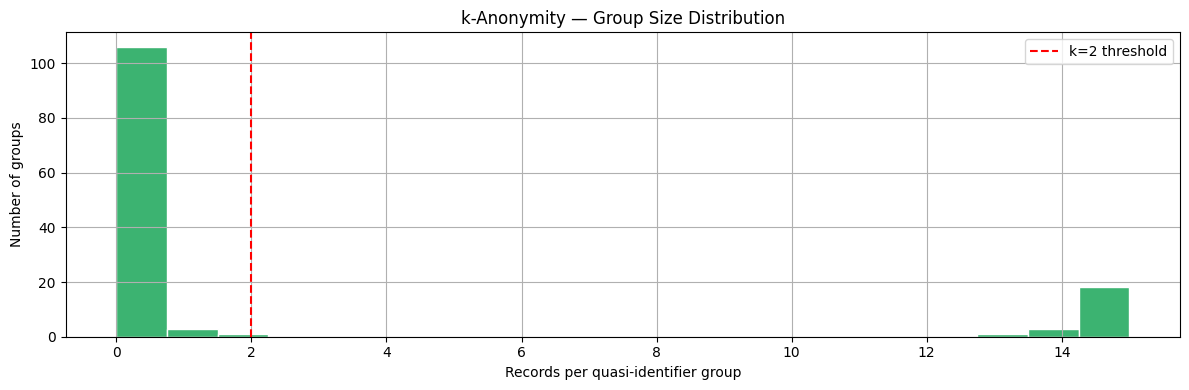

In [22]:
K_THRESHOLD = 2    # minimum acceptable k; raise to 5 for stricter privacy

df['word_count_bucket'] = pd.cut(
    df['word_count'],
    bins=[0, 20, 40, 60, 80, 120, 999],
    labels=['0-20', '21-40', '41-60', '61-80', '81-120', '120+']
)

quasi_ids   = ['word_count_bucket', 'label']
group_sizes = df.groupby(quasi_ids).size().reset_index(name='group_size')
violations  = group_sizes[group_sizes['group_size'] < K_THRESHOLD]

print(f"k-Anonymity check  (k ≥ {K_THRESHOLD})")
print(f"─────────────────────────────────────────")
print(f"Total quasi-id groups  : {len(group_sizes)}")
print(f"Groups satisfying k≥{K_THRESHOLD}  : {len(group_sizes) - len(violations)}")
print(f"Groups VIOLATING  k≥{K_THRESHOLD}  : {len(violations)}")

if len(violations) > 0:
    print(f"\n⚠️  Violation details:")
    print(violations.to_string(index=False))
    print("\n  → Recommendation: merge rare condition groups or increase dataset size.")
else:
    print(f"\n✅  All groups satisfy k ≥ {K_THRESHOLD}. No unique records detectable.")

# Visualise group size distribution
plt.figure(figsize=(12, 4))
group_sizes['group_size'].hist(bins=20, color='mediumseagreen', edgecolor='white')
plt.axvline(K_THRESHOLD, color='red', linestyle='--', label=f'k={K_THRESHOLD} threshold')
plt.title('k-Anonymity — Group Size Distribution')
plt.xlabel('Records per quasi-identifier group')
plt.ylabel('Number of groups')
plt.legend()
plt.tight_layout()
plt.show()


✅ Differential Privacy applied (ε = 1.0)
   Noise scale (Laplace b) : 1.0000
   X_train original shape  : (264, 1029)
   X_train (DP) shape      : (264, 1029)

   Privacy budget spent    : ε = 1.00

   Feature value comparison (row 0, first 5 features):
   Original : [0.2831 0.     0.     0.     0.    ]
   With DP  : [1.     1.     1.     0.8214 0.    ]


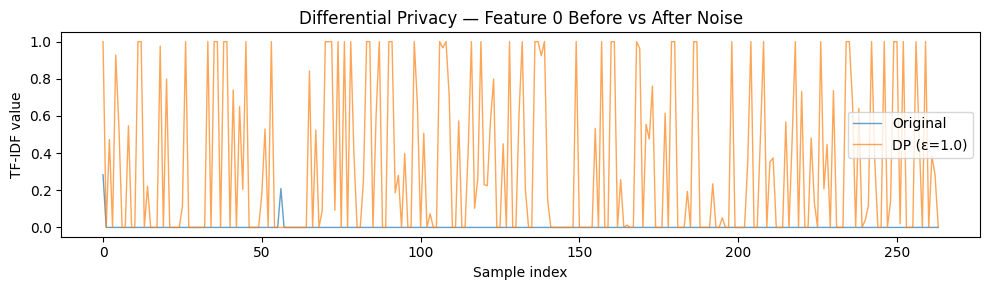


💡 Use X_train_dp (instead of X_train) when fitting your AI model.


In [23]:
EPSILON     = 1.0        # privacy budget — tune as needed
SENSITIVITY = 1.0        # L1 sensitivity of TF-IDF features (bounded 0–1)

def apply_laplace_dp(X_sparse, epsilon, sensitivity):
    """
    Add Laplace noise to a sparse matrix for differential privacy.
    Returns a dense numpy array (clipped to [0, 1] for TF-IDF validity).
    """
    X_dense = X_sparse.toarray().astype(float)
    scale   = sensitivity / epsilon
    noise   = np.random.laplace(loc=0.0, scale=scale, size=X_dense.shape)
    X_noisy = X_dense + noise
    X_noisy = np.clip(X_noisy, 0.0, 1.0)    # TF-IDF values must stay in [0,1]
    return X_noisy

# Apply to training set ONLY — never add noise to test set
X_train_dense      = X_train.toarray().astype(float)
X_train_dp         = apply_laplace_dp(X_train, EPSILON, SENSITIVITY)

# Also build a diffprivlib BoundedMean to demonstrate the library
accountant = dp.BudgetAccountant(epsilon=EPSILON, delta=0)

dp_mean = dp.tools.mean(
    X_train_dense[:, :10],          # demo on first 10 features
    epsilon=EPSILON,
    bounds=(0.0, 1.0),
    accountant=accountant,
    axis=0
)

print(f"✅ Differential Privacy applied (ε = {EPSILON})")
print(f"   Noise scale (Laplace b) : {SENSITIVITY / EPSILON:.4f}")
print(f"   X_train original shape  : {X_train.shape}")
print(f"   X_train (DP) shape      : {X_train_dp.shape}")
print(f"\n   Privacy budget spent    : ε = {accountant.total()[0]:.2f}")

# Compare a few values before/after
print(f"\n   Feature value comparison (row 0, first 5 features):")
print(f"   Original : {X_train_dense[0, :5].round(4)}")
print(f"   With DP  : {X_train_dp[0,   :5].round(4)}")

# Visualise noise effect on one feature
plt.figure(figsize=(10, 3))
plt.plot(X_train_dense[:, 0], label='Original', alpha=0.7, linewidth=1)
plt.plot(X_train_dp[:, 0],    label=f'DP (ε={EPSILON})', alpha=0.7, linewidth=1)
plt.title('Differential Privacy — Feature 0 Before vs After Noise')
plt.xlabel('Sample index')
plt.ylabel('TF-IDF value')
plt.legend()
plt.tight_layout()
plt.show()

print("\n💡 Use X_train_dp (instead of X_train) when fitting your AI model.")
